# Inception — Sleep Stage Classification · EDA

**Задача.** По 21 физиологическому признаку (мощности EEG по диапазонам, EMG, EOG,
пульс, дыхание, SpO₂, движения тела) предсказать стадию сна `sleep_stage` ∈ {0, 1, 2, 3}.

**Метрика.** Классы сбалансированы → ориентируемся на **accuracy**.

**Цель этого ноутбука.** Только разведка данных (EDA): понять структуру, пропуски,
распределения, связь признаков с целью и есть ли сдвиг между train и test.
Модель — в отдельном ноутбуке.

## 1. Импорты и загрузка данных

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")        # единый аккуратный стиль графиков
pd.set_option("display.max_columns", 30)

# данные лежат рядом, в папке data/
train = pd.read_csv("data/train.csv")
test  = pd.read_csv("data/test.csv")

print("train:", train.shape, " test:", test.shape)
train.head()

train: (9000, 23)  test: (5000, 22)


,id,eeg_delta_power,eeg_theta_power,eeg_alpha_power,eeg_sigma_power,eeg_beta_power,eeg_gamma_power,eeg_slow_osc_power,eeg_spectral_entropy,eeg_spindle_density,eeg_kcomplex_rate,emg_chin_tone,emg_tone_variance,eog_movement_density,eog_amplitude,heart_rate_mean,heart_rate_variability,respiration_rate,respiration_variability,spo2_mean,body_movement_index,eog_burst_index,sleep_stage
0,0,-1.51474,1.40728,10.33510,-1.61350,3.73081,0.99850,1.85689,-3.24253,-1.27096,-1.66370,2.79720,-1.76807,2.65567,1.98733,1.60184,-2.49794,-0.59521,1.71154,1.93342,1.57365,-1.36230,1
1,1,-0.28998,0.89706,1.62494,2.41580,-2.70265,-0.10131,-1.68955,0.01442,-2.87943,-0.03516,0.66264,-0.35469,4.36423,0.09942,3.38567,-0.56386,2.16016,-4.32301,1.07270,-2.43903,-0.37271,2
2,2,3.35435,0.32987,-5.41547,2.38680,-2.90584,-2.93372,-3.11713,-0.04647,1.61782,-0.53028,-2.08711,1.49050,-3.87561,-0.87681,-2.84480,5.08383,-4.60411,0.37967,-2.06913,2.67324,NaN,3
3,3,-1.44917,-0.04374,1.71560,-1.27770,-0.19007,2.21826,1.69621,0.39756,0.00534,-0.65535,0.98192,1.12176,1.41415,0.39275,0.55060,-2.12910,2.32790,0.78319,0.98233,1.53824,-0.25040,1
4,4,1.35898,-2.36720,-7.40779,5.31815,-2.55954,-5.13284,-5.26634,1.73985,1.04618,-1.04615,-2.74524,-0.31044,-0.55616,0.86588,-1.96343,4.30036,0.22130,-1.44020,1.35760,-3.07701,-1.04947,3


## 2. Общий осмотр: типы и описательная статистика

In [6]:
# типы колонок и пропуски одним взглядом
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       9000 non-null   int64  
 1   eeg_delta_power          9000 non-null   float64
 2   eeg_theta_power          9000 non-null   float64
 3   eeg_alpha_power          9000 non-null   float64
 4   eeg_sigma_power          9000 non-null   float64
 5   eeg_beta_power           9000 non-null   float64
 6   eeg_gamma_power          9000 non-null   float64
 7   eeg_slow_osc_power       9000 non-null   float64
 8   eeg_spectral_entropy     9000 non-null   float64
 9   eeg_spindle_density      9000 non-null   float64
 10  eeg_kcomplex_rate        9000 non-null   float64
 11  emg_chin_tone            9000 non-null   float64
 12  emg_tone_variance        9000 non-null   float64
 13  eog_movement_density     9000 non-null   float64
 14  eog_amplitude           

In [7]:
# описательная статистика по признакам (без id)
train.drop(columns=["id"]).describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
eeg_delta_power,9000.0,-0.015,2.431,-9.567,-1.688,-0.012,1.622,8.798
eeg_theta_power,9000.0,-0.034,2.408,-8.277,-1.649,-0.020,1.604,9.222
eeg_alpha_power,9000.0,-0.016,5.042,-20.632,-3.465,0.019,3.419,18.870
eeg_sigma_power,9000.0,0.012,2.207,-7.948,-1.460,-0.001,1.512,9.603
eeg_beta_power,9000.0,-0.010,2.883,-11.460,-1.963,0.005,1.956,10.027
eeg_gamma_power,9000.0,-0.011,2.428,-9.638,-1.652,0.010,1.635,8.296
eeg_slow_osc_power,9000.0,-0.014,2.801,-14.123,-1.873,0.023,1.866,10.362
eeg_spectral_entropy,9000.0,0.010,2.753,-9.301,-1.859,-0.028,1.882,10.160
eeg_spindle_density,9000.0,0.006,2.174,-8.828,-1.484,0.024,1.479,8.937
eeg_kcomplex_rate,9000.0,0.007,1.948,-8.090,-1.299,-0.002,1.314,7.064


Признаки уже стандартизованы (среднее ≈ 0). Это синтетические данные —
масштабирование почти не повлияет на деревья, но пригодится линейным моделям.

## 3. Целевая переменная — баланс классов

In [8]:
counts = train["sleep_stage"].value_counts().sort_index()
print(counts)
print("\nдоли, %:")
print((counts / len(train) * 100).round(2))

sleep_stage
0    2001
1    2442
2    2237
3    2320
Name: count, dtype: int64

доли, %:
sleep_stage
0    22.23
1    27.13
2    24.86
3    25.78
Name: count, dtype: float64


/var/folders/ph/mnfl_fnx1lxfylcfnh1hmt1c0000gn/T/ipykernel_4396/311829197.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


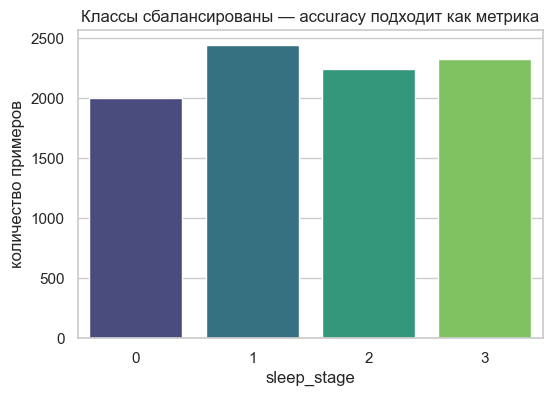

In [9]:
# столбчатая диаграмма распределения классов
plt.figure(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values, palette="viridis")
plt.title("Классы сбалансированы — accuracy подходит как метрика")
plt.xlabel("sleep_stage")
plt.ylabel("количество примеров")
plt.show()

**Вывод.** Все 4 класса представлены примерно поровну (22–27%).
Базовая модель «всегда предсказываю самый частый класс» даст ≈ 27% accuracy — это наш нижний ориентир.

## 4. Пропуски

In [10]:
# где есть пропуски в train и test
miss = pd.DataFrame({
    "train_na": train.isna().sum(),
    "test_na":  test.isna().sum(),
})
miss[miss.sum(axis=1) > 0]

,train_na,test_na
eog_burst_index,4501,2477.0


Пропуски только в `eog_burst_index` — примерно половина значений и в train, и в test.
Важный вопрос: **сам факт пропуска связан со стадией сна?** Если да — добавим флаг-признак.

In [7]:
# распределение классов там, где eog_burst_index пропущен vs заполнен
miss_flag = train["eog_burst_index"].isna()
tab = pd.crosstab(miss_flag, train["sleep_stage"], normalize="index").round(3)
tab.index = ["заполнен", "пропущен"]
print(tab)

sleep_stage      0      1      2      3
заполнен     0.229  0.273  0.246  0.251
пропущен     0.216  0.269  0.251  0.264


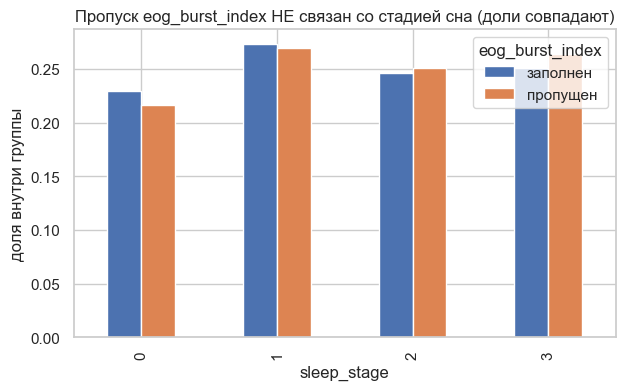

In [8]:
# то же самое графиком
tab.T.plot(kind="bar", figsize=(7, 4))
plt.title("Пропуск eog_burst_index НЕ связан со стадией сна (доли совпадают)")
plt.xlabel("sleep_stage")
plt.ylabel("доля внутри группы")
plt.legend(title="eog_burst_index")
plt.show()

**Вывод.** Доли классов почти одинаковые → пропущенность неинформативна.
Достаточно простого заполнения (медиана/0), флаг-признак вряд ли поможет, но проверим в модели.

In [13]:
corr = train.corr(numeric_only=True)['eog_burst_index'].sort_values()
print(corr)

sleep_stage               -0.400307
eeg_alpha_power           -0.324505
eeg_sigma_power           -0.284271
eog_movement_density      -0.277716
respiration_rate          -0.252654
eeg_slow_osc_power        -0.223127
spo2_mean                 -0.212775
body_movement_index       -0.179109
respiration_variability   -0.164563
eeg_delta_power           -0.093481
eeg_theta_power           -0.053958
eeg_gamma_power           -0.025506
emg_tone_variance         -0.019027
id                        -0.001240
emg_chin_tone              0.073150
eeg_spindle_density        0.075409
eeg_spectral_entropy       0.097341
heart_rate_variability     0.113290
heart_rate_mean            0.120712
eog_amplitude              0.143244
eeg_beta_power             0.201337
eeg_kcomplex_rate          0.478922
eog_burst_index            1.000000
Name: eog_burst_index, dtype: float64


In [15]:
train.groupby('sleep_stage')['eog_burst_index'].mean()

sleep_stage
0    0.986995
1   -0.646810
2    0.479567
3   -0.705594
Name: eog_burst_index, dtype: float64

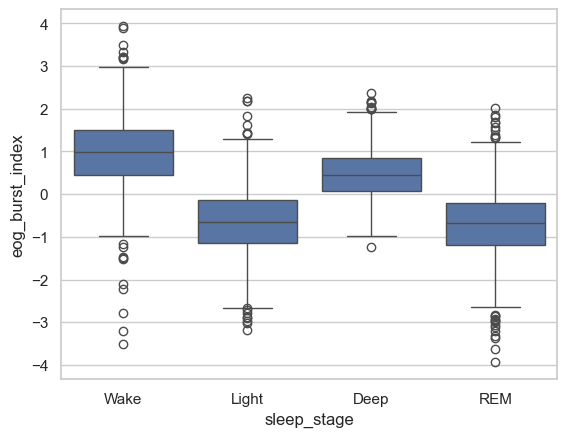

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=train,
    x='sleep_stage',
    y='eog_burst_index'
)

plt.xticks(
    [0,1,2,3],
    ['Wake','Light','Deep','REM']
)
plt.show()

## 5. Распределения признаков

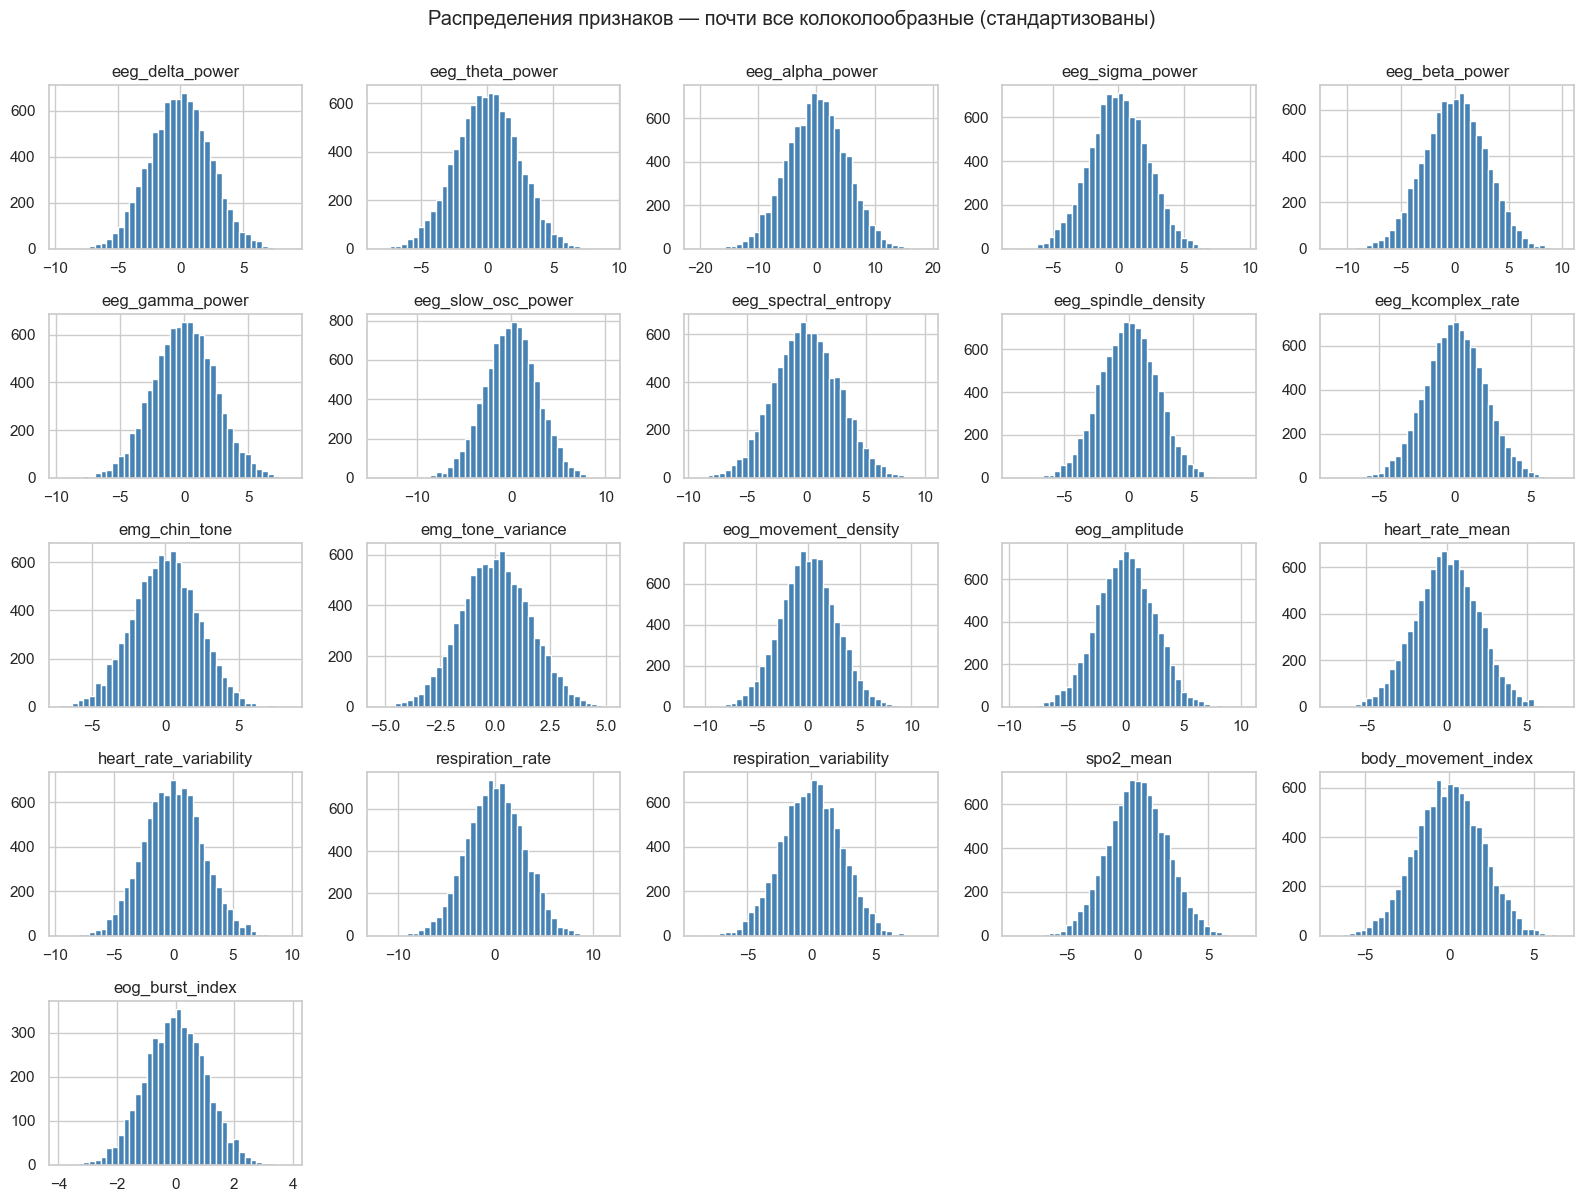

In [9]:
# гистограммы всех числовых признаков, чтобы увидеть форму и выбросы
features = [c for c in train.columns if c not in ("id", "sleep_stage")]

train[features].hist(figsize=(16, 12), bins=40, color="steelblue", edgecolor="white")
plt.suptitle("Распределения признаков — почти все колоколообразные (стандартизованы)", y=1.0)
plt.tight_layout()
plt.show()

## 6. Корреляции между признаками

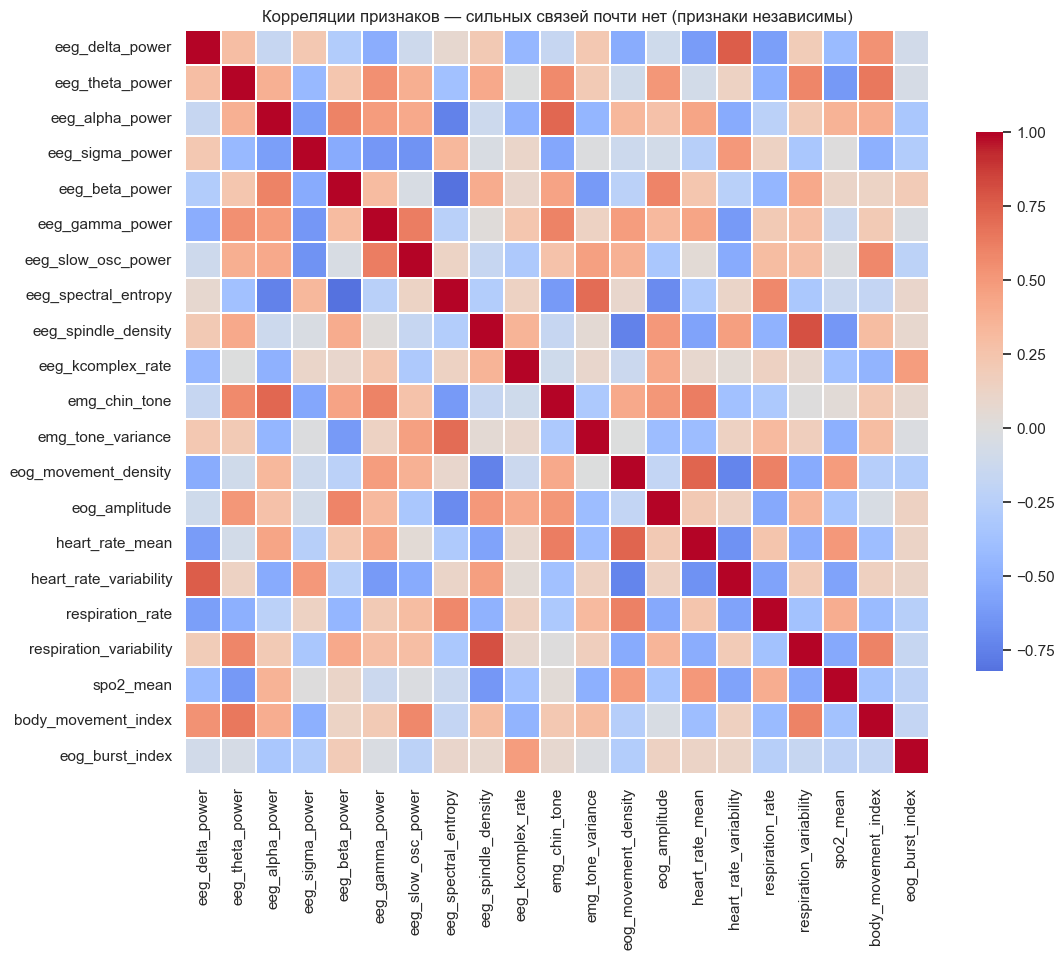

In [10]:
# тепловая карта корреляций — ищем дубли/сильно связанные признаки
corr = train[features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            linewidths=0.3, cbar_kws={"shrink": 0.7})
plt.title("Корреляции признаков — сильных связей почти нет (признаки независимы)")
plt.show()

**Вывод.** Сильных корреляций между признаками нет — значит лишних дублей мало,
и каждый признак несёт свою информацию (или шум). Линейная мультиколлинеарность не мешает.

## 7. Какие признаки разделяют классы

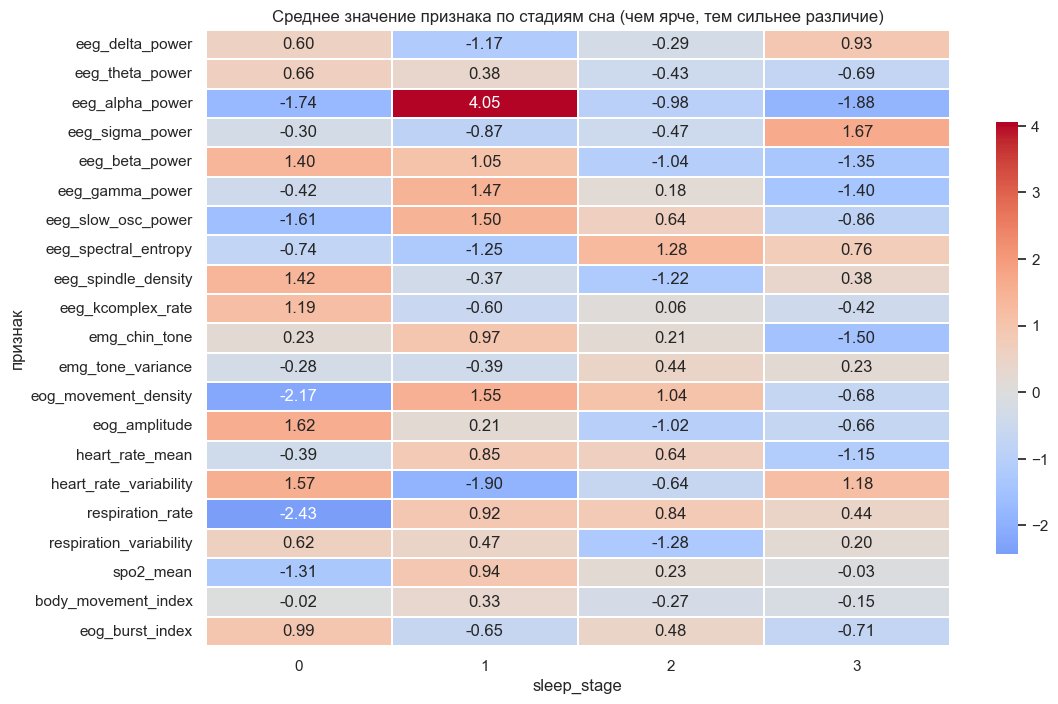

In [11]:
# средние значения каждого признака по классам (z-score уже, поэтому сравнимы)
means_by_class = train.groupby("sleep_stage")[features].mean()

plt.figure(figsize=(12, 8))
sns.heatmap(means_by_class.T, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            linewidths=0.3, cbar_kws={"shrink": 0.7})
plt.title("Среднее значение признака по стадиям сна (чем ярче, тем сильнее различие)")
plt.xlabel("sleep_stage")
plt.ylabel("признак")
plt.show()

Признаки с большим разбросом средних между классами — самые полезные.
Посмотрим на топ из них подробнее «ящиками».

/var/folders/ph/mnfl_fnx1lxfylcfnh1hmt1c0000gn/T/ipykernel_4271/732315310.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x="sleep_stage", y=col, ax=ax, palette="viridis")
/var/folders/ph/mnfl_fnx1lxfylcfnh1hmt1c0000gn/T/ipykernel_4271/732315310.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x="sleep_stage", y=col, ax=ax, palette="viridis")
/var/folders/ph/mnfl_fnx1lxfylcfnh1hmt1c0000gn/T/ipykernel_4271/732315310.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x="sleep_stage", y=col, ax=ax, pa

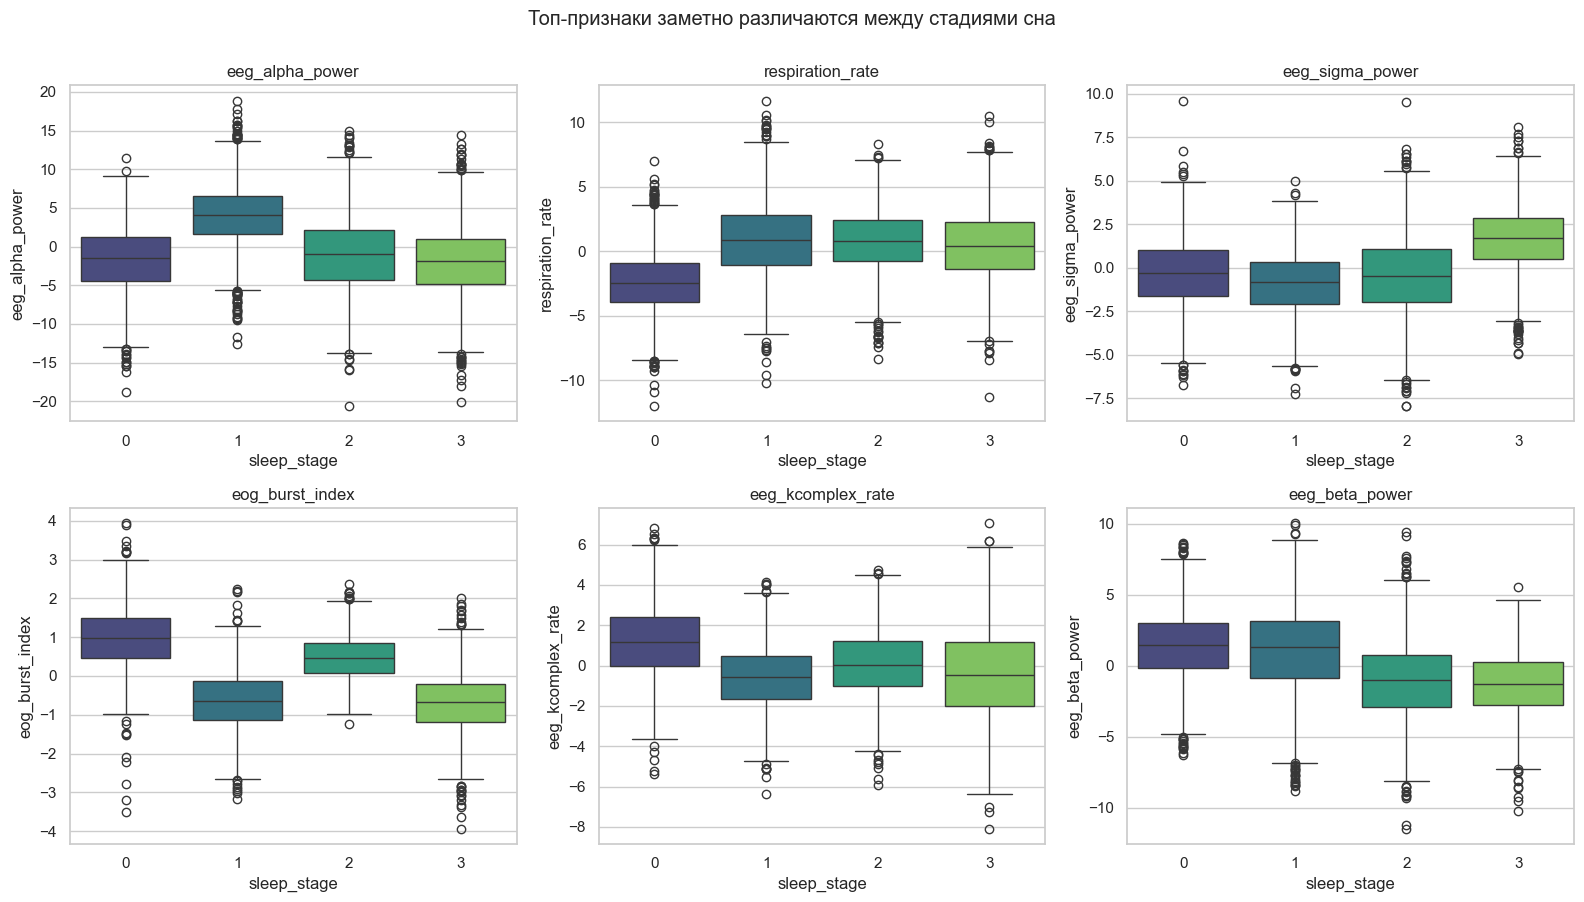

In [12]:
# boxplot'ы топ-признаков по классам — видно, как они разделяют стадии
top = ["eeg_alpha_power", "respiration_rate", "eeg_sigma_power",
       "eog_burst_index", "eeg_kcomplex_rate", "eeg_beta_power"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), top):
    sns.boxplot(data=train, x="sleep_stage", y=col, ax=ax, palette="viridis")
    ax.set_title(col)
plt.suptitle("Топ-признаки заметно различаются между стадиями сна", y=1.0)
plt.tight_layout()
plt.show()

## 8. Быстрая оценка важности признаков

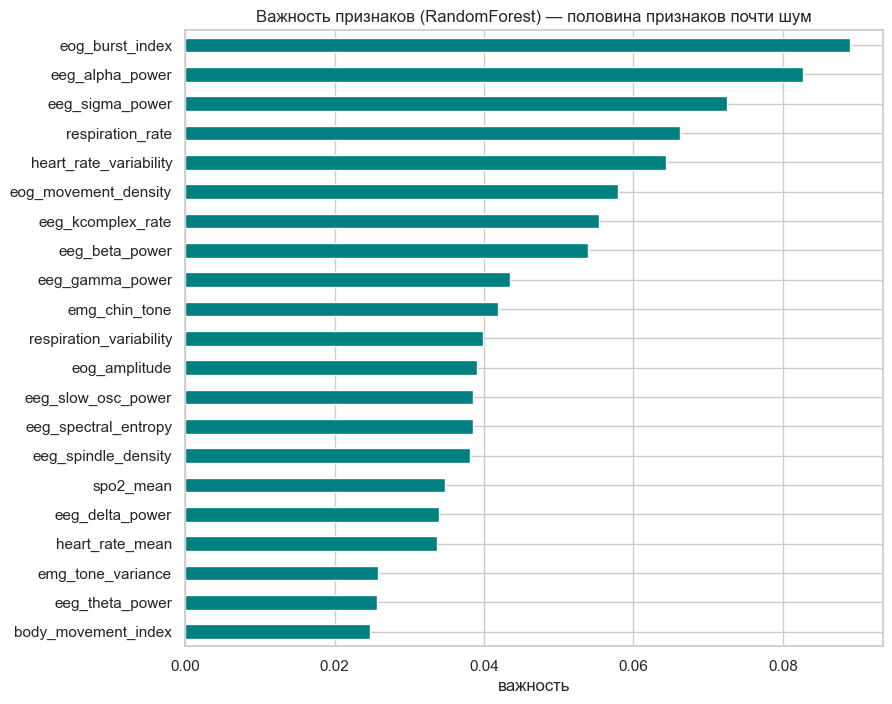

In [13]:
# обучим лёгкую модель ТОЛЬКО ради рейтинга важности (не финальная модель)
from sklearn.ensemble import RandomForestClassifier

X = train[features].fillna(0)          # eog_burst_index -> 0 (данные стандартизованы)
y = train["sleep_stage"]

rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42).fit(X, y)
imp = pd.Series(rf.feature_importances_, index=features).sort_values()

plt.figure(figsize=(9, 8))
imp.plot(kind="barh", color="teal")
plt.title("Важность признаков (RandomForest) — половина признаков почти шум")
plt.xlabel("важность")
plt.show()

**Вывод.** Несколько признаков (`eeg_alpha_power`, `respiration_rate`, `eeg_sigma_power`,
`eog_burst_index`, `eeg_kcomplex_rate`, `eeg_beta_power`) несут основную информацию.
Многие признаки слабые — но удалять их пока не будем, деревья сами их игнорируют.

In [11]:
corr = df.corr(numeric_only=True)['eog_burst_index'].sort_values()
print(corr)

NameError: name 'df' is not defined

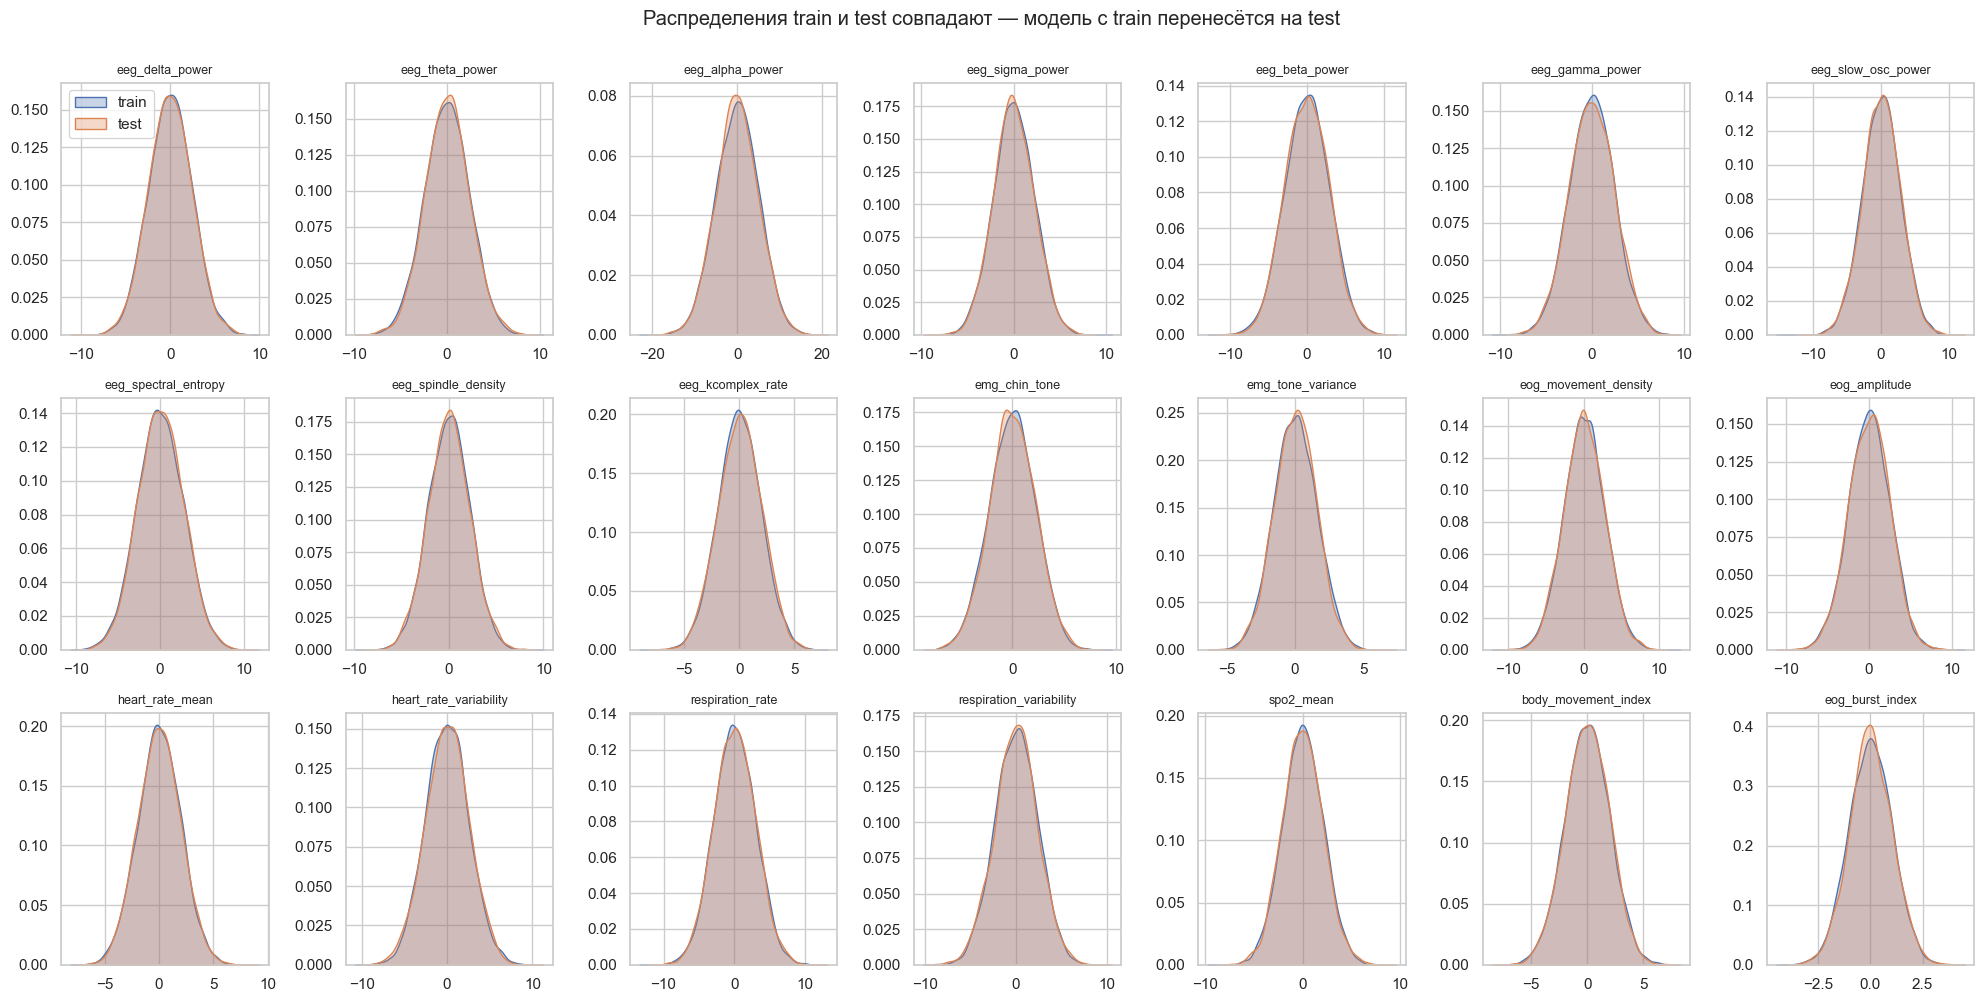

In [14]:
# сравним распределения признаков в train и test — нет ли сдвига (covariate shift)
fig, axes = plt.subplots(3, 7, figsize=(20, 10))
for ax, col in zip(axes.ravel(), features):
    sns.kdeplot(train[col].dropna(), ax=ax, label="train", fill=True, alpha=0.3)
    sns.kdeplot(test[col].dropna(),  ax=ax, label="test",  fill=True, alpha=0.3)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("")
axes.ravel()[0].legend()
plt.suptitle("Распределения train и test совпадают — модель с train перенесётся на test", y=1.0)
plt.tight_layout()
plt.show()

## 10. Итоги EDA

- **Задача.** 4-классовая классификация стадий сна, классы сбалансированы → метрика accuracy.
- **Признаки.** 21 числовой, уже стандартизованы, слабо коррелируют между собой.
- **Пропуски.** Только `eog_burst_index` (~50%); пропуск неинформативен → простое заполнение.
- **Важность.** ~6 признаков несут сигнал, остальные близки к шуму.
- **Train vs test.** Распределения совпадают → переобучения под сдвиг можно не бояться.

**План на ноутбук с моделью:**
1. Базовая линия: «самый частый класс» (~0.27) и логистическая регрессия.
2. Деревья: RandomForest / ExtraTrees / HistGradientBoosting (ожидаем ~0.80–0.82).
3. Кросс-валидация (StratifiedKFold, 5 фолдов) для честной оценки.
4. Ансамбль (soft voting) лучших моделей.
5. Позже — LightGBM / XGBoost для финального прироста.
6. Обучение на всём train → предсказание test → `submission.csv` в формате `id, sleep_stage`.